# Predicting Hospital Readmission using Python and SQL
By Jack Guo

## Introduction
Hospital readmission rates are often utilized as a measure of care quality and patient outcomes. The Center for Medicare and Medicaid services (CMS) has penalized hospitals for excess readmission rates since 2012 under the Hospital Readmissions Reduction Program [^1]. Identifying patients at high risk of readmission at the time of discharge allows clinicians to potentially reduce patient burden and hospital costs.

This project uses the MIMIC-IV Clinical Database Demo, a publicly available de-identified dataset containing clinical records from patients admitted to Beth Israel Deaconess Medical Center in Boston, Massachusetts. This demo dataset contains records for approximately 100 patients across multiple relational tables covering hospital admissions, ICU stays, laboratory results, diagnoses, and more.

The primary goal of this project is to build a logistic regression model predicting whether a patient will be readmitted in 30 days using features derived from demographics, admission characteristics, and ICU utilization. A second goal is to demonstrate a reproducible clinical data pipeline: raw relational data extracted using SQL, processed in Python, and analyzed using binary logistic regression.

The analysis proceeds as follows: exploratory data analysis characterizes the patient cohort and admission patterns; feature engineering constructs the target variable and predictors from multiple joined tables; a logistic regression model is then fit and evaluated using area under the ROC curve (AUC) as the primary performance metric.

[^1]: https://www.cms.gov/medicare/quality/value-based-programs/hospital-readmissions

# Exploratory Data Analysis

We begin exporatory data analysis by loading the MIMIC-IV demo dataset into a SQLite database, enabling SQL-based queries using Python. The dataset consists of many relational tables organized into hosp (hosp_) and icu (icu_) folders, each linked by common patient and admission identifiers (subject_id, hadm_id, stay_id).

In [202]:
%%capture

import os
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from great_tables import GT, html

os.chdir("C:/Users/flami/Documents/MIMIC-IV Analysis/MIMIC-IV-EDA")

# create sqlite db
root_folder = "."
conn = sqlite3.connect("mimic.db")

for root, dirs, files in os.walk(root_folder):
    for filename in files:
        if filename.endswith(".csv"):
            filepath = os.path.join(root, filename)

            # change file names to folder_name
            if root_folder == root:
                tablename = filename.replace(".csv", "")
            else:
                subfolder = os.path.basename(root)
                tablename = f"{subfolder}_{filename}".replace(".csv", "")

            # read to db
            df = pd.read_csv(filepath)
            df.to_sql(tablename, conn, if_exists="replace", index=False)

The four key tables for this analysis are previewed along with their schema. hosp_patients includes demographic information such as gender and anchor age, MIMIC-IV's de-identified age feature. hosp_admissions contains admission and discharge timestamps, admission type, and race, serving as the primary table for linking patient stays. hosp_labevents contains laboratory measurements taken during admissions, which contains a lot of missing entries. icu_icustays records ICU-specific stay information including care unit type and duration, with no missing values in the key columns.

In [203]:
# get schema and preview a table

for table in ("hosp_patients", "hosp_admissions", "hosp_labevents", "icu_icustays"):

    schema = pd.read_sql(f"PRAGMA table_info({table})", conn)
    schema_table = (GT(schema)
     .tab_header(
         title=f"Schema for {table}"
     )
    )
    display(schema_table)

    preview = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn)
    prev_table = (GT(preview)
         .tab_header(
             title=f"Preview for {table}"
         )
        )
    display(prev_table)

GT(_tbl_data=   cid               name     type  notnull dflt_value  pk
0    0         subject_id  INTEGER        0       None   0
1    1             gender     TEXT        0       None   0
2    2         anchor_age  INTEGER        0       None   0
3    3        anchor_year  INTEGER        0       None   0
4    4  anchor_year_group     TEXT        0       None   0
5    5                dod     TEXT        0       None   0, _body=<great_tables._gt_data.Body object at 0x00000231377B32F0>, _boxhead=Boxhead([ColInfo(var='cid', type=<ColInfoTypeEnum.default: 1>, column_label='cid', column_align='right', column_width=None), ColInfo(var='name', type=<ColInfoTypeEnum.default: 1>, column_label='name', column_align='left', column_width=None), ColInfo(var='type', type=<ColInfoTypeEnum.default: 1>, column_label='type', column_align='left', column_width=None), ColInfo(var='notnull', type=<ColInfoTypeEnum.default: 1>, column_label='notnull', column_align='right', column_width=None), ColInfo(var='dflt_value', type=<ColInfoTypeEnum.default: 1>, column_label='dflt_value', column_align='right', column_width=None), ColInfo(var='pk', type=<ColInfoTypeEnum.default: 1>, column_label='pk', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000231377B1CD0>, _spanners=Spanners([]), _heading=Heading(title='Schema for hosp_patients', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x00000231377B2510>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x00000231377B0320>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x00000231377B06E0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='sol

GT(_tbl_data=   subject_id gender  anchor_age  anchor_year anchor_year_group         dod
0    10014729      F          21         2125       2011 - 2013         NaN
1    10003400      F          72         2134       2011 - 2013  2137-09-02
2    10002428      F          80         2155       2011 - 2013         NaN
3    10032725      F          38         2143       2011 - 2013  2143-03-30
4    10027445      F          48         2142       2011 - 2013  2146-02-09, _body=<great_tables._gt_data.Body object at 0x00000231377B2120>, _boxhead=Boxhead([ColInfo(var='subject_id', type=<ColInfoTypeEnum.default: 1>, column_label='subject_id', column_align='right', column_width=None), ColInfo(var='gender', type=<ColInfoTypeEnum.default: 1>, column_label='gender', column_align='left', column_width=None), ColInfo(var='anchor_age', type=<ColInfoTypeEnum.default: 1>, column_label='anchor_age', column_align='right', column_width=None), ColInfo(var='anchor_year', type=<ColInfoTypeEnum.default: 1>, column_label='anchor_year', column_align='right', column_width=None), ColInfo(var='anchor_year_group', type=<ColInfoTypeEnum.default: 1>, column_label='anchor_year_group', column_align='right', column_width=None), ColInfo(var='dod', type=<ColInfoTypeEnum.default: 1>, column_label='dod', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000231377B30B0>, _spanners=Spanners([]), _heading=Heading(title='Preview for hosp_patients', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002313690C4D0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002313690F650>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002313690CF20>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value

GT(_tbl_data=    cid                  name     type  notnull dflt_value  pk
0     0            subject_id  INTEGER        0       None   0
1     1               hadm_id  INTEGER        0       None   0
2     2             admittime     TEXT        0       None   0
3     3             dischtime     TEXT        0       None   0
4     4             deathtime     TEXT        0       None   0
5     5        admission_type     TEXT        0       None   0
6     6     admit_provider_id     TEXT        0       None   0
7     7    admission_location     TEXT        0       None   0
8     8    discharge_location     TEXT        0       None   0
9     9             insurance     TEXT        0       None   0
10   10              language     TEXT        0       None   0
11   11        marital_status     TEXT        0       None   0
12   12                  race     TEXT        0       None   0
13   13             edregtime     TEXT        0       None   0
14   14             edouttime     TEXT        0       None   0
15   15  hospital_expire_flag  INTEGER        0       None   0, _body=<great_tables._gt_data.Body object at 0x000002313690EFF0>, _boxhead=Boxhead([ColInfo(var='cid', type=<ColInfoTypeEnum.default: 1>, column_label='cid', column_align='right', column_width=None), ColInfo(var='name', type=<ColInfoTypeEnum.default: 1>, column_label='name', column_align='left', column_width=None), ColInfo(var='type', type=<ColInfoTypeEnum.default: 1>, column_label='type', column_align='left', column_width=None), ColInfo(var='notnull', type=<ColInfoTypeEnum.default: 1>, column_label='notnull', column_align='right', column_width=None), ColInfo(var='dflt_value', type=<ColInfoTypeEnum.default: 1>, column_label='dflt_value', column_align='right', column_width=None), ColInfo(var='pk', type=<ColInfoTypeEnum.default: 1>, column_label='pk', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002313690C770>, _spanners=Spanners([]), _heading=Heading(title='Schema for hosp_admissions', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002313690C170>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002313690C6B0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002313690E450>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'),

GT(_tbl_data=   subject_id   hadm_id            admittime            dischtime  \
0    10004235  24181354  2196-02-24 14:38:00  2196-03-04 14:02:00   
1    10009628  25926192  2153-09-17 17:08:00  2153-09-25 13:20:00   
2    10018081  23983182  2134-08-18 02:02:00  2134-08-23 19:35:00   
3    10006053  22942076  2111-11-13 23:39:00  2111-11-15 17:20:00   
4    10031404  21606243  2113-08-04 18:46:00  2113-08-06 20:57:00   

             deathtime admission_type admit_provider_id  \
0                  NaN         URGENT            P03YMR   
1                  NaN         URGENT            P41R5N   
2                  NaN         URGENT            P233F6   
3  2111-11-15 17:20:00         URGENT            P38TI6   
4                  NaN         URGENT            P07HDB   

       admission_location        discharge_location insurance language  \
0  TRANSFER FROM HOSPITAL  SKILLED NURSING FACILITY  Medicaid  ENGLISH   
1  TRANSFER FROM HOSPITAL          HOME HEALTH CARE  Medicaid        ?   
2  TRANSFER FROM HOSPITAL  SKILLED NURSING FACILITY  Medicare  ENGLISH   
3  TRANSFER FROM HOSPITAL                      DIED  Medicaid  ENGLISH   
4  TRANSFER FROM HOSPITAL                      HOME     Other  ENGLISH   

  marital_status                            race            edregtime  \
0         SINGLE              BLACK/CAPE VERDEAN  2196-02-24 12:15:00   
1        MARRIED  HISPANIC/LATINO - PUERTO RICAN                  NaN   
2        MARRIED                           WHITE  2134-08-17 16:24:00   
3            NaN                         UNKNOWN                  NaN   
4        WIDOWED                           WHITE                  NaN   

             edouttime  hospital_expire_flag  
0  2196-02-24 17:07:00                     0  
1                  NaN                     0  
2  2134-08-18 03:15:00                     0  
3                  NaN                     1  
4                  NaN                     0  , _body=<great_tables._gt_data.Body object at 0x000002313690EAE0>, _boxhead=Boxhead([ColInfo(var='subject_id', type=<ColInfoTypeEnum.default: 1>, column_label='subject_id', column_align='right', column_width=None), ColInfo(var='hadm_id', type=<ColInfoTypeEnum.default: 1>, column_label='hadm_id', column_align='right', column_width=None), ColInfo(var='admittime', type=<ColInfoTypeEnum.default: 1>, column_label='admittime', column_align='right', column_width=None), ColInfo(var='dischtime', type=<ColInfoTypeEnum.default: 1>, column_label='dischtime', column_align='right', column_width=None), ColInfo(var='deathtime', type=<ColInfoTypeEnum.default: 1>, column_label='deathtime', column_align='right', column_width=None), ColInfo(var='admission_type', type=<ColInfoTypeEnum.default: 1>, column_label='admission_type', column_align='left', column_width=None), ColInfo(var='admit_provider_id', type=<ColInfoTypeEnum.default: 1>, column_label='admit_provider_id', column_align='left', column_width=None), ColInfo(var='admission_location', type=<ColInfoTypeEnum.default: 1>, column_label='admission_location', column_align='left', column_width=None), ColInfo(var='discharge_location', type=<ColInfoTypeEnum.default: 1>, column_label='discharge_location', column_align='left', column_width=None), ColInfo(var='insurance', type=<ColInfoTypeEnum.default: 1>, column_label='insurance', column_align='left', column_width=None), ColInfo(var='language', type=<ColInfoTypeEnum.default: 1>, column_label='language', column_align='left', column_width=None), ColInfo(var='marital_status', type=<ColInfoTypeEnum.default: 1>, column_label='marital_status', column_align='left', column_width=None), ColInfo(var='race', type=<ColInfoTypeEnum.default: 1>, column_label='race', column_align='left', column_width=None), ColInfo(var='edregtime', type=<ColInfoTypeEnum.default: 1>, column_label='edregtime', column_align='right', column_width=None), ColInfo(var='edouttime', type=<ColInfoTypeEnum.default: 1>, column_label='edouttime', column_align='right', column_width=None

GT(_tbl_data=    cid               name     type  notnull dflt_value  pk
0     0        labevent_id  INTEGER        0       None   0
1     1         subject_id  INTEGER        0       None   0
2     2            hadm_id     REAL        0       None   0
3     3        specimen_id  INTEGER        0       None   0
4     4             itemid  INTEGER        0       None   0
5     5  order_provider_id     TEXT        0       None   0
6     6          charttime     TEXT        0       None   0
7     7          storetime     TEXT        0       None   0
8     8              value     TEXT        0       None   0
9     9           valuenum     REAL        0       None   0
10   10           valueuom     TEXT        0       None   0
11   11    ref_range_lower     REAL        0       None   0
12   12    ref_range_upper     REAL        0       None   0
13   13               flag     TEXT        0       None   0
14   14           priority     TEXT        0       None   0
15   15           comments     TEXT        0       None   0, _body=<great_tables._gt_data.Body object at 0x000002313690CDD0>, _boxhead=Boxhead([ColInfo(var='cid', type=<ColInfoTypeEnum.default: 1>, column_label='cid', column_align='right', column_width=None), ColInfo(var='name', type=<ColInfoTypeEnum.default: 1>, column_label='name', column_align='left', column_width=None), ColInfo(var='type', type=<ColInfoTypeEnum.default: 1>, column_label='type', column_align='left', column_width=None), ColInfo(var='notnull', type=<ColInfoTypeEnum.default: 1>, column_label='notnull', column_align='right', column_width=None), ColInfo(var='dflt_value', type=<ColInfoTypeEnum.default: 1>, column_label='dflt_value', column_align='right', column_width=None), ColInfo(var='pk', type=<ColInfoTypeEnum.default: 1>, column_label='pk', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002313690FAA0>, _spanners=Spanners([]), _heading=Heading(title='Schema for hosp_labevents', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002313690EC00>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002313690C7D0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002313690D6D0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, categ

GT(_tbl_data=   labevent_id  subject_id     hadm_id  specimen_id  itemid order_provider_id  \
0       172061    10014354  29600294.0      1808066   51277              None   
1       172062    10014354  29600294.0      1808066   51279              None   
2       172068    10014354  29600294.0      1808066   52172              None   
3       172063    10014354  29600294.0      1808066   51301              None   
4       172050    10014354  29600294.0      1808066   51249              None   

             charttime            storetime value  valuenum valueuom  \
0  2148-08-16 00:00:00  2148-08-16 01:30:00  15.4     15.40        %   
1  2148-08-16 00:00:00  2148-08-16 01:30:00  3.35      3.35     m/uL   
2  2148-08-16 00:00:00  2148-08-16 01:30:00  49.7     49.70       fL   
3  2148-08-16 00:00:00  2148-08-16 01:30:00  20.3     20.30     K/uL   
4  2148-08-16 00:00:00  2148-08-16 01:30:00  31.1     31.10     g/dL   

   ref_range_lower  ref_range_upper      flag priority comments  
0             10.5             15.5       NaN  ROUTINE     None  
1              4.6              6.1  abnormal  ROUTINE     None  
2             35.1             46.3  abnormal  ROUTINE     None  
3              4.0             10.0  abnormal  ROUTINE     None  
4             32.0             37.0  abnormal  ROUTINE     None  , _body=<great_tables._gt_data.Body object at 0x000002313690F440>, _boxhead=Boxhead([ColInfo(var='labevent_id', type=<ColInfoTypeEnum.default: 1>, column_label='labevent_id', column_align='right', column_width=None), ColInfo(var='subject_id', type=<ColInfoTypeEnum.default: 1>, column_label='subject_id', column_align='right', column_width=None), ColInfo(var='hadm_id', type=<ColInfoTypeEnum.default: 1>, column_label='hadm_id', column_align='right', column_width=None), ColInfo(var='specimen_id', type=<ColInfoTypeEnum.default: 1>, column_label='specimen_id', column_align='right', column_width=None), ColInfo(var='itemid', type=<ColInfoTypeEnum.default: 1>, column_label='itemid', column_align='right', column_width=None), ColInfo(var='order_provider_id', type=<ColInfoTypeEnum.default: 1>, column_label='order_provider_id', column_align='right', column_width=None), ColInfo(var='charttime', type=<ColInfoTypeEnum.default: 1>, column_label='charttime', column_align='right', column_width=None), ColInfo(var='storetime', type=<ColInfoTypeEnum.default: 1>, column_label='storetime', column_align='right', column_width=None), ColInfo(var='value', type=<ColInfoTypeEnum.default: 1>, column_label='value', column_align='right', column_width=None), ColInfo(var='valuenum', type=<ColInfoTypeEnum.default: 1>, column_label='valuenum', column_align='right', column_width=None), ColInfo(var='valueuom', type=<ColInfoTypeEnum.default: 1>, column_label='valueuom', column_align='left', column_width=None), ColInfo(var='ref_range_lower', type=<ColInfoTypeEnum.default: 1>, column_label='ref_range_lower', column_align='right', column_width=None), ColInfo(var='ref_range_upper', type=<ColInfoTypeEnum.default: 1>, column_label='ref_range_upper', column_align='right', column_width=None), ColInfo(var='flag', type=<ColInfoTypeEnum.default: 1>, column_label='flag', column_align='left', column_width=None), ColInfo(var='priority', type=<ColInfoTypeEnum.default: 1>, column_label='priority', column_align='left', column_width=None), ColInfo(var='comments', type=<ColInfoTypeEnum.default: 1>, column_label='comments', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002313690FF50>, _spanners=Spanners([]), _heading=Heading(title='Preview for hosp_labevents', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002313690DEB0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002313690F560>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002313690E960>, _formats=[], _substitutions=[], _col_merge=[], _transfor

GT(_tbl_data=   cid            name     type  notnull dflt_value  pk
0    0      subject_id  INTEGER        0       None   0
1    1         hadm_id  INTEGER        0       None   0
2    2         stay_id  INTEGER        0       None   0
3    3  first_careunit     TEXT        0       None   0
4    4   last_careunit     TEXT        0       None   0
5    5          intime     TEXT        0       None   0
6    6         outtime     TEXT        0       None   0
7    7             los     REAL        0       None   0, _body=<great_tables._gt_data.Body object at 0x000002313690E6F0>, _boxhead=Boxhead([ColInfo(var='cid', type=<ColInfoTypeEnum.default: 1>, column_label='cid', column_align='right', column_width=None), ColInfo(var='name', type=<ColInfoTypeEnum.default: 1>, column_label='name', column_align='left', column_width=None), ColInfo(var='type', type=<ColInfoTypeEnum.default: 1>, column_label='type', column_align='left', column_width=None), ColInfo(var='notnull', type=<ColInfoTypeEnum.default: 1>, column_label='notnull', column_align='right', column_width=None), ColInfo(var='dflt_value', type=<ColInfoTypeEnum.default: 1>, column_label='dflt_value', column_align='right', column_width=None), ColInfo(var='pk', type=<ColInfoTypeEnum.default: 1>, column_label='pk', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000231377B3BF0>, _spanners=Spanners([]), _heading=Heading(title='Schema for icu_icustays', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002313690E1E0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002313690FDA0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002313690DB80>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), t

GT(_tbl_data=   subject_id   hadm_id   stay_id  \
0    10018328  23786647  31269608   
1    10020187  24104168  37509585   
2    10020187  26842957  32554129   
3    10012853  27882036  31338022   
4    10020740  25826145  32145159   

                                    first_careunit        last_careunit  \
0                                   Neuro Stepdown       Neuro Stepdown   
1  Neuro Surgical Intensive Care Unit (Neuro SICU)       Neuro Stepdown   
2                               Neuro Intermediate   Neuro Intermediate   
3                              Trauma SICU (TSICU)  Trauma SICU (TSICU)   
4                              Trauma SICU (TSICU)  Trauma SICU (TSICU)   

                intime              outtime       los  
0  2154-04-24 23:03:44  2154-05-02 15:55:21  7.702512  
1  2169-01-15 04:56:00  2169-01-20 15:47:50  5.452662  
2  2170-02-24 18:18:46  2170-02-25 15:15:26  0.872685  
3  2176-11-26 02:34:49  2176-11-29 20:58:54  3.766725  
4  2150-06-03 20:12:32  2150-06-04 21:05:58  1.037106  , _body=<great_tables._gt_data.Body object at 0x000002313690FEF0>, _boxhead=Boxhead([ColInfo(var='subject_id', type=<ColInfoTypeEnum.default: 1>, column_label='subject_id', column_align='right', column_width=None), ColInfo(var='hadm_id', type=<ColInfoTypeEnum.default: 1>, column_label='hadm_id', column_align='right', column_width=None), ColInfo(var='stay_id', type=<ColInfoTypeEnum.default: 1>, column_label='stay_id', column_align='right', column_width=None), ColInfo(var='first_careunit', type=<ColInfoTypeEnum.default: 1>, column_label='first_careunit', column_align='left', column_width=None), ColInfo(var='last_careunit', type=<ColInfoTypeEnum.default: 1>, column_label='last_careunit', column_align='left', column_width=None), ColInfo(var='intime', type=<ColInfoTypeEnum.default: 1>, column_label='intime', column_align='right', column_width=None), ColInfo(var='outtime', type=<ColInfoTypeEnum.default: 1>, column_label='outtime', column_align='right', column_width=None), ColInfo(var='los', type=<ColInfoTypeEnum.default: 1>, column_label='los', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x000002313690C560>, _spanners=Spanners([]), _heading=Heading(title='Preview for icu_icustays', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x000002313690CC80>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002313690C830>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002313690F3E0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category

We check for missing and distinct values in the set of important tables. While there are missing values for some of the variables in a few tables, most notably in hosp_labevents (where order_provider_id, flag, and comments are largely missing) and hosp_admissions (where deathtime is missing for surviving patients). No variable with missing values will be used in our regression model so no imputation was performed. Each table contains records for 100 unique patients, which is consistent with the MIMIC-IV demo's stated patient count.

In [204]:
for table in ("hosp_patients", "hosp_admissions", "hosp_labevents", "icu_icustays"):
    df = pd.read_sql(f"SELECT * FROM {table}", conn)
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"No missing values in {table}")
    else:
        missing_table = (GT(missing.to_frame(name='count'))
            .tab_header(
                title=f"Missing count for {table}"
            )   
        )
        display(missing_table)

Missing count for hosp_patients
count
69


Missing count for hosp_admissions
count
260
42
12
93
93


Missing count for hosp_labevents
count
28420
90897
992
9588
12481
16203
18728
18728
67452


No missing values in icu_icustays


In [205]:
for table in ("hosp_patients", "hosp_admissions", "hosp_labevents", "icu_icustays"):
    df = pd.read_sql(f"SELECT COUNT(DISTINCT subject_id) AS dist FROM {table}", conn)
    print(f"DISTINCT Values in {table}: " + str(df['dist'][0]))

DISTINCT Values in hosp_patients: 100
DISTINCT Values in hosp_admissions: 100
DISTINCT Values in hosp_labevents: 100
DISTINCT Values in icu_icustays: 100


MIMIC-IV de-identifies patients, meaning rather than an exact age, we're given an anchor age. An anchor age is the age of a patient taken within a three year window. While this introduces uncertainty if we use age as a predictor, older anchor ages still refer to older patients and are associated with a higher baseline risk. 

We can see that the patient cohort skews older, with most patients in the 45-90 age range and a notably higher concentration in 65-70 age group. This is consistent with the demographic typically at risk for serious conditions that require hospitalization. 

The distribution of hospital length of stay is heavily skewed right, with most stays lasting fewer than 10 days but a long tail extending to over 40 days, reflecting a small number of complex, prolonged admissions.

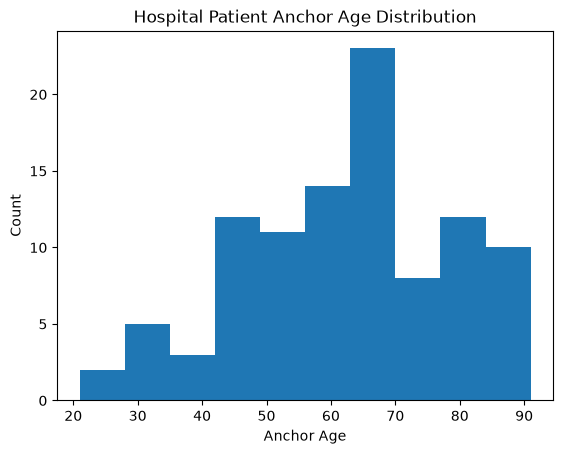

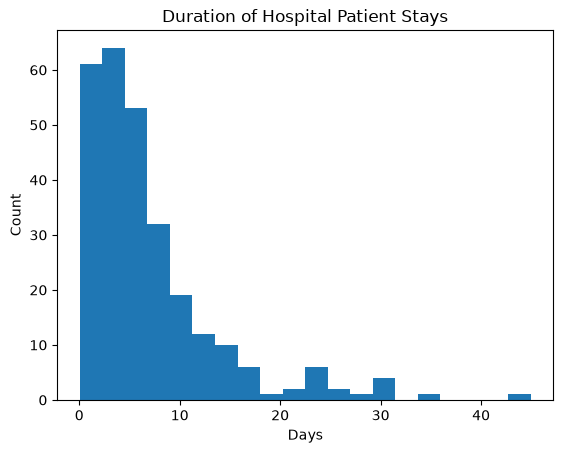

In [206]:
# age distribution for hosp patients
hosp_pat_ages = pd.read_sql("""
SELECT anchor_age, COUNT(*) as n FROM hosp_patients
GROUP BY anchor_age
ORDER BY anchor_age
""", conn)

plt.hist(hosp_pat_ages["anchor_age"], weights=hosp_pat_ages["n"])
plt.title("Hospital Patient Anchor Age Distribution")
plt.xlabel("Anchor Age")
plt.ylabel("Count")
plt.show()

# num of each gender
pd.read_sql("SELECT gender, COUNT(*) AS n FROM hosp_patients GROUP BY gender", conn)

# duration of stay
durations = pd.read_sql("""
    SELECT admission_type, (julianday(dischtime) - julianday(admittime)) AS stay_duration
    FROM hosp_admissions
""", conn)

# plot duration of stay
plt.hist(durations["stay_duration"], bins=20)
plt.title("Duration of Hospital Patient Stays")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()



Emergency Ward Emergency (EW EMER.) admissions dominate the cohort with 104 admissions. Despite being the most frequent admission type, EW EMER. admissions have a moderate average stay duration of approximately 7 days, while Urgent and Direct Emergency admissions show the longest average stays. This suggests that these patients may present with more complex acute conditions requiring extended care.

GT(_tbl_data=                admission_type  count
0       AMBULATORY OBSERVATION      5
1                 DIRECT EMER.     15
2           DIRECT OBSERVATION      7
3                     ELECTIVE     13
4               EU OBSERVATION     30
5                     EW EMER.    104
6            OBSERVATION ADMIT     45
7  SURGICAL SAME DAY ADMISSION     18
8                       URGENT     38, _body=<great_tables._gt_data.Body object at 0x000002313694DAC0>, _boxhead=Boxhead([ColInfo(var='admission_type', type=<ColInfoTypeEnum.default: 1>, column_label='admission_type', column_align='left', column_width=None), ColInfo(var='count', type=<ColInfoTypeEnum.default: 1>, column_label='count', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000023131F74F20>, _spanners=Spanners([]), _heading=Heading(title='Admission Type Counts', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023132B45EE0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x000002316FCA32F0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x000002316FCA2090>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_

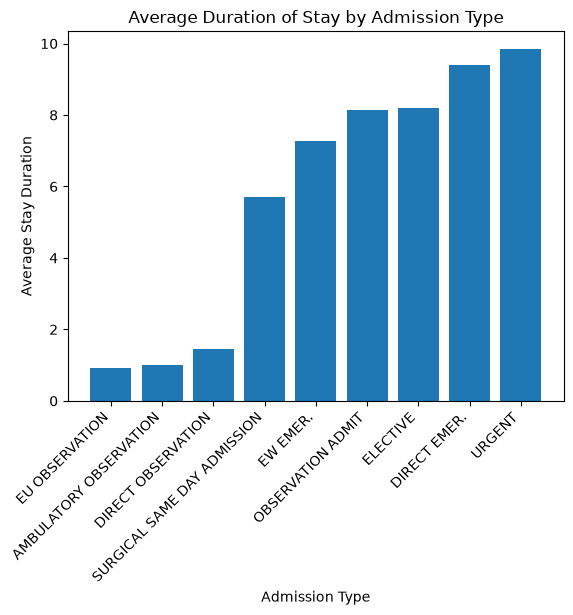

In [207]:
# dist of admission types
admissions = pd.read_sql("SELECT admission_type, COUNT(*) AS count FROM hosp_admissions GROUP BY admission_type", conn)
admissions_table = (GT(admissions)
 .tab_header(
     title="Admission Type Counts"
 )
)
display(admissions_table)

# remove table for tests
conn.execute("DROP TABLE IF EXISTS dur_by_type")

# compare avg stay times for each type of admission
conn.execute("""CREATE TABLE IF NOT EXISTS dur_by_type AS
             SELECT admission_type, AVG(stay_duration) as avg
             FROM (SELECT admission_type, (julianday(dischtime) - julianday(admittime)) AS stay_duration FROM hosp_admissions)
             GROUP BY admission_type
             ORDER BY avg
             """)

duration_by_type = pd.read_sql("SELECT * FROM dur_by_type", conn)


plt.bar(duration_by_type["admission_type"], duration_by_type["avg"])
plt.title("Average Duration of Stay by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Stay Duration")
plt.xticks(rotation=45, ha="right")
plt.show()

# Feature Engineering

The analytical dataset is constructed in two steps. Firstly, the 30-day readmission target variable is derived by self-joining hosp_admissions to identify the earliest readmission for each patient. An admission is labeled as readmitted (1) if the next admission occurred within 30 days of discharge, and not readmitted (0) otherwise. This common-table-expression-based approach handles the time-ordering logic entirely within SQL before any data is pulled into Python.

In [208]:
readmissions = pd.read_sql("""
    WITH admit_pairs AS (
        SELECT 
            a1.subject_id,
            a1.hadm_id,
            a1.dischtime,
            MIN(a2.admittime) as next_admittime
        FROM hosp_admissions a1
        LEFT JOIN hosp_admissions a2 ON 
            a1.subject_id = a2.subject_id
            AND a2.admittime > a1.dischtime
        GROUP BY a1.subject_id, a1.hadm_id, a1.dischtime
    )
    SELECT *,
    CASE
        WHEN julianday(next_admittime) - julianday(dischtime) <= 30
        THEN 1 ELSE 0
    END AS readmitted_30_day
    FROM admit_pairs
""", conn)

readmissions_table=(GT(readmissions.head(5))
 .tab_header(
     title="Readmission Preview"
 )
)
display(readmissions_table)

GT(_tbl_data=   subject_id   hadm_id            dischtime       next_admittime  \
0    10000032  22595853  2180-05-07 17:15:00  2180-06-26 18:27:00   
1    10000032  22841357  2180-06-27 18:49:00  2180-07-23 12:35:00   
2    10000032  25742920  2180-08-07 17:50:00                  NaN   
3    10000032  29079034  2180-07-25 17:55:00  2180-08-05 23:44:00   
4    10001217  24597018  2157-11-25 18:00:00  2157-12-18 16:58:00   

   readmitted_30_day  
0                  0  
1                  1  
2                  0  
3                  1  
4                  1  , _body=<great_tables._gt_data.Body object at 0x000002314967B650>, _boxhead=Boxhead([ColInfo(var='subject_id', type=<ColInfoTypeEnum.default: 1>, column_label='subject_id', column_align='right', column_width=None), ColInfo(var='hadm_id', type=<ColInfoTypeEnum.default: 1>, column_label='hadm_id', column_align='right', column_width=None), ColInfo(var='dischtime', type=<ColInfoTypeEnum.default: 1>, column_label='dischtime', column_align='right', column_width=None), ColInfo(var='next_admittime', type=<ColInfoTypeEnum.default: 1>, column_label='next_admittime', column_align='right', column_width=None), ColInfo(var='readmitted_30_day', type=<ColInfoTypeEnum.default: 1>, column_label='readmitted_30_day', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000231325520F0>, _spanners=Spanners([]), _heading=Heading(title='Readmission Preview', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000023132553110>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000023132552F60>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000023132552BA0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_bord

The readmissions table above shows the first five rows of the target variable construction. Patient 10000032 had four admissions — two flagged as readmitted (next admission within 30 days) and two not. The next_admittime is NaN for their final admission, correctly receiving a value of 0 since no subsequent admission exists to evaluate.

Patient level features are extracted by joining hosp_admissions with hosp_patients (patient demographics) and icu_icustays (ICU utilization). A LEFT JOIN on icu_icustays ensures all admissions are retained. Patients without an ICU stay receive had_icu_stay = 0 and icu_los_days = 0 via COALESCE, rather than NULL values that would be dropped during modeling. The readmissions and features dataframes are then joined on hadm_id to create the final analytical dataset.  

In [209]:
# select features for model
features_df = pd.read_sql("""
    SELECT a.hadm_id, p.gender, p.anchor_age, a.admission_type, a.race,
    julianday(a.dischtime)-julianday(a.admittime) as los_days, 
    CASE WHEN i.stay_id IS NOT NULL THEN 1 ELSE 0 END AS had_icu_stay,
    COALESCE(JULIANDAY(i.outtime) - JULIANDAY(i.intime), 0) AS icu_los_days
    FROM hosp_admissions a
    JOIN hosp_patients p ON a.subject_id = p.subject_id
    LEFT JOIN icu_icustays i ON a.hadm_id = i.hadm_id
""", conn)
# los = length of stay

# final df
final_df = readmissions.merge(features_df, on='hadm_id', how='left')

# Data Preparation

The class distribution shows a substantial imbalance: 232 admissions (81%) were not readmitted within 30 days, while 55 (19%) were. This reflects the real-world readmission rate and is common in clinical prediction tasks. To address this imbalance, logistic regression is fit with class_weight='balanced', which adjusts the loss function to penalize misclassification of the minority class (readmissions) more heavily.

Categorical variables (gender, admission type, and race) are encoded as integers using LabelEncoder prior to model fitting, since logistic regression requires numeric inputs. The dataset is then split into training (80%) and test (20%) sets using a fixed random seed for reproducibility.

In [210]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# check class counts
display(final_df['readmitted_30_day'].value_counts())
display(final_df['readmitted_30_day'].value_counts(normalize=True))

# encode categorical variables
for col in ['gender', 'admission_type', 'race']:
    final_df[col] = LabelEncoder().fit_transform(final_df[col].astype(str))

X = final_df[['anchor_age', 'gender', 'admission_type', 'race',
              'los_days', 'had_icu_stay', 'icu_los_days']]
y = final_df['readmitted_30_day']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

readmitted_30_day
0    232
1     55
Name: count, dtype: int64

readmitted_30_day
0    0.808362
1    0.191638
Name: proportion, dtype: float64

# Modeling

A logistic regression model is fit on the training set using the balanced class weighting described above. Logistic regression is appropriate here given the binary outcome (readmitted vs. not), the relatively small dataset size, and the primary goal of interpretability. Coefficient-based odds ratios allow direct interpretation of each feature's relationship with readmission risk. 

In [211]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

# fit model
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# roc auc scores
print(f"AUC: {roc_auc_score(y_test, y_prob):.3f}")
print(classification_report(y_test, y_pred))

# coefficient table
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': np.round(model.coef_[0], 3),
    'odds_ratio': np.round(np.exp(model.coef_[0]), 3)
}).sort_values('odds_ratio', ascending=False)

coef_tab = (GT(coef_df)
 .tab_header(title="Coefficient Table")
)
display(coef_tab)

conn.close()

AUC: 0.462
              precision    recall  f1-score   support

           0       0.81      0.65      0.72        46
           1       0.24      0.42      0.30        12

    accuracy                           0.60        58
   macro avg       0.52      0.53      0.51        58
weighted avg       0.69      0.60      0.64        58



GT(_tbl_data=          feature  coefficient  odds_ratio
5    had_icu_stay        0.191       1.210
2  admission_type        0.076       1.079
4        los_days        0.039       1.040
3            race        0.036       1.037
0      anchor_age       -0.023       0.978
6    icu_los_days       -0.117       0.889
1          gender       -0.956       0.384, _body=<great_tables._gt_data.Body object at 0x0000023132B45D90>, _boxhead=Boxhead([ColInfo(var='feature', type=<ColInfoTypeEnum.default: 1>, column_label='feature', column_align='left', column_width=None), ColInfo(var='coefficient', type=<ColInfoTypeEnum.default: 1>, column_label='coefficient', column_align='right', column_width=None), ColInfo(var='odds_ratio', type=<ColInfoTypeEnum.default: 1>, column_label='odds_ratio', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000231425F6180>, _spanners=Spanners([]), _heading=Heading(title='Coefficient Table', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x00000231709B0380>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x00000231709B0140>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x00000231709B3440>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=Opti

The model achieved an AUC of 0.462, which is below the 0.5 random baseline. This indicates that the model as specified does not meaningfully discriminate between readmitted and non-readmitted patients in this test set. This result is not unexpected given the small sample size (287 total admissions, 55 positive cases), the limited feature set, and the use of the demo dataset rather than the full MIMIC-IV cohort. The coefficient table shows ICU stay and longer length of stay are associated with slightly higher readmission odds. Female gender shows a large protective coefficient, which is most likely due to encoding artifacts rather than a true clinical effect, and warrants caution when interpreting.

Despite the weak discriminative performance, this analysis demonstrates the end-to-end clinical data pipeline: multi-table SQL extraction, feature engineering via CTE-based self-joins, and Python-based modeling.

# Discussion and Limitations
Several limitations should be acknowledged. The MIMIC-IV demo dataset contains only 100 patients and approximately 287 admissions, which is much too small to build a reliable 30-day readmission prediction model. The full MIMIC-IV dataset contains over 300,000 patients and would be more suitable for this goal.

The feature set is intentionally minimal and omits potentially stronger predictors such as diagnosis codes, laboratory values, and medication histories. Additionally, LabelEncoder assigns arbitrary integers to nominal categorical variables like race and admission type, which may introduce artificial ordinal relationships that could distort model coefficients. One-hot encoding would be more appropriate in future renditions of this project. 

Future work could apply this pipeline to the full MIMIC-IV cohort, incorporate diagnosis codes and lab features, use one-hot encoding for categoricals, and explore regularized models (LASSO logistic regression) or tree-based methods that better handle class imbalance and non-linear relationships.